In [75]:
import torchvision
from torch.utils.data import DataLoader
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
from torchvision.datasets import MNIST
from torch.optim import Adam
from sklearn.metrics import f1_score

In [76]:
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

In [77]:
import torchvision
from torchvision import transforms

# MNIST dataset
root_path = '/home/storopoli/Downloads' # mude isso no Colab se necessário

# Pequena transformação para tensores e normalizando o tamanho
trans = transforms.Compose([transforms.Grayscale(num_output_channels=3), transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=trans)

In [78]:
from torchvision import transforms

# Novas transformações com Resize e Normalização ImageNet
trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Recarregando os datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=trans, download=True)

# Atualizando os DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)


In [79]:
batch_size=32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [80]:
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [81]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [82]:
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(512, 10)

from torch.optim import Adam

parametros_para_treinar = filter(lambda p: p.requires_grad, model.parameters())

optimizer = Adam(parametros_para_treinar, lr=0.001)

In [83]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [84]:
model.to(device)
total_step = len(train_loader)

metricas = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

# Listas vazias
loss_list = []
acc_list = []

train_loss_epoch = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        running_corrects += torch.sum(predicted == labels.data)

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    metricas['train_loss'].append(epoch_loss)
    metricas['train_acc'].append(epoch_acc.cpu().item())

    print(f">>> Final da Época {epoch+1}: Loss Média: {epoch_loss:.4f}, Acc Média: {epoch_acc:.4f}")

    model.eval()
    val_loss_cum = 0.0
    val_corrects = 0
    y_true_epoch = []
    y_pred_epoch = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss_cum += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_corrects += torch.sum(predicted == labels.data)

            y_true_epoch.extend(labels.cpu().numpy())
            y_pred_epoch.extend(predicted.cpu().numpy())



    metricas['val_loss'].append(val_loss_cum / len(test_dataset))
    metricas['val_acc'].append(val_corrects.double() / len(test_dataset))
    metricas['val_f1'].append(f1_score(y_true_epoch, y_pred_epoch, average='weighted'))

    print(f"F1-Score: {metricas['val_f1'][-1]:.4f}")

Época [1/6], Step [100/1875], Loss: 0.6006
Época [1/6], Step [200/1875], Loss: 0.5212
Época [1/6], Step [300/1875], Loss: 0.3428
Época [1/6], Step [400/1875], Loss: 0.3463
Época [1/6], Step [500/1875], Loss: 0.2792
Época [1/6], Step [600/1875], Loss: 0.1959
Época [1/6], Step [700/1875], Loss: 0.2466
Época [1/6], Step [800/1875], Loss: 0.3668
Época [1/6], Step [900/1875], Loss: 0.3324
Época [1/6], Step [1000/1875], Loss: 0.1774
Época [1/6], Step [1100/1875], Loss: 0.1917
Época [1/6], Step [1200/1875], Loss: 0.0545
Época [1/6], Step [1300/1875], Loss: 0.1963
Época [1/6], Step [1400/1875], Loss: 0.2416
Época [1/6], Step [1500/1875], Loss: 0.1640
Época [1/6], Step [1600/1875], Loss: 0.1685
Época [1/6], Step [1700/1875], Loss: 0.2549
Época [1/6], Step [1800/1875], Loss: 0.3505
>>> Final da Época 1: Loss Média: 0.3501, Acc Média: 0.9065
F1-Score: 0.9517
Época [2/6], Step [100/1875], Loss: 0.1364
Época [2/6], Step [200/1875], Loss: 0.3805
Época [2/6], Step [300/1875], Loss: 0.3639
Época [2/6]

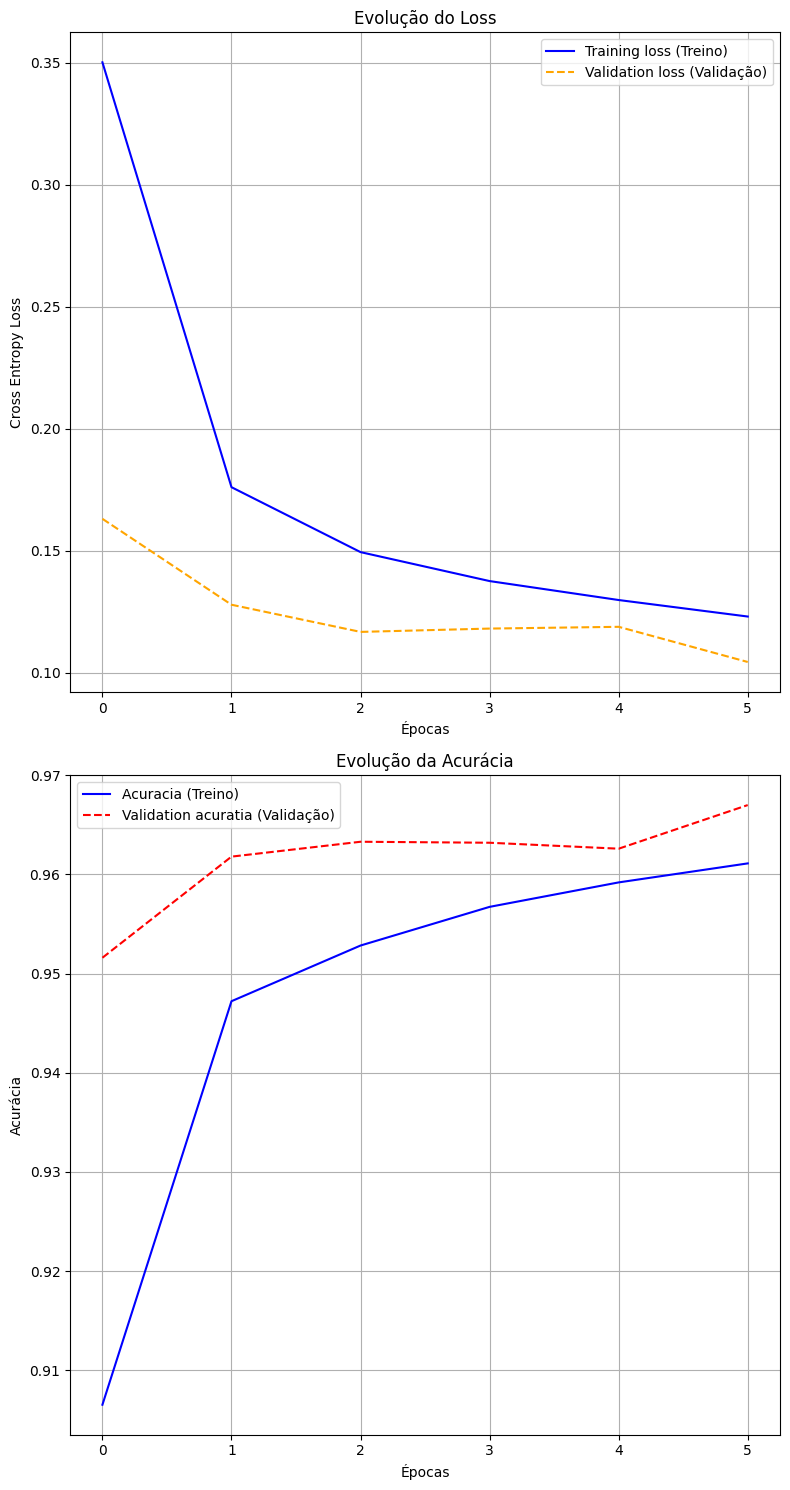

In [85]:
import matplotlib.pyplot as plt

fig, (ax1, ay1) = plt.subplots(2, 1, figsize=(8, 15))

ax1.plot(metricas['train_loss'], label=f'Training loss (Treino)', color='blue', linestyle='-')
ax1.plot(metricas['val_loss'], label=f'Validation loss (Validação)', color='orange', linestyle='--')

ax1.set_title("Evolução do Loss")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True)

ay1.plot(metricas['train_acc'], label=f'Acuracia (Treino)', color='blue', linestyle='-')

ay1.plot([acc.cpu().item() for acc in metricas['val_acc']], label=f'Validation acuratia (Validação)', color='red', linestyle='--')

ay1.set_title("Evolução da Acurácia")
ay1.set_xlabel("Épocas")
ay1.set_ylabel("Acurácia")
ay1.legend()
ay1.grid(True)

plt.tight_layout()
plt.show()

In [86]:
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

In [87]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [88]:
import torch.nn as nn
from torch.optim import Adam

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(512, 10)

parametros_para_treinar = filter(lambda p: p.requires_grad, model.parameters())
optimizer = Adam(parametros_para_treinar, lr=0.001)


In [56]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [89]:
model.to(device)
total_step = len(train_loader)

metricas = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

# Listas vazias
loss_list = []
acc_list = []

train_loss_epoch = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        running_corrects += torch.sum(predicted == labels.data)

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    metricas['train_loss'].append(epoch_loss)
    metricas['train_acc'].append(epoch_acc.cpu().item())

    print(f">>> Final da Época {epoch+1}: Loss Média: {epoch_loss:.4f}, Acc Média: {epoch_acc:.4f}")

    model.eval()
    val_loss_cum = 0.0
    val_corrects = 0
    y_true_epoch = []
    y_pred_epoch = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss_cum += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_corrects += torch.sum(predicted == labels.data)

            y_true_epoch.extend(labels.cpu().numpy())
            y_pred_epoch.extend(predicted.cpu().numpy())



    metricas['val_loss'].append(val_loss_cum / len(test_dataset))
    metricas['val_acc'].append(val_corrects.double() / len(test_dataset))
    metricas['val_f1'].append(f1_score(y_true_epoch, y_pred_epoch, average='weighted'))

    print(f"F1-Score: {metricas['val_f1'][-1]:.4f}")

Época [1/6], Step [100/1875], Loss: 0.2379
Época [1/6], Step [200/1875], Loss: 0.2594
Época [1/6], Step [300/1875], Loss: 0.0796
Época [1/6], Step [400/1875], Loss: 0.0803
Época [1/6], Step [500/1875], Loss: 0.0719
Época [1/6], Step [600/1875], Loss: 0.0064
Época [1/6], Step [700/1875], Loss: 0.0034
Época [1/6], Step [800/1875], Loss: 0.0351
Época [1/6], Step [900/1875], Loss: 0.1331
Época [1/6], Step [1000/1875], Loss: 0.4658
Época [1/6], Step [1100/1875], Loss: 0.0069
Época [1/6], Step [1200/1875], Loss: 0.0211
Época [1/6], Step [1300/1875], Loss: 0.0089
Época [1/6], Step [1400/1875], Loss: 0.0012
Época [1/6], Step [1500/1875], Loss: 0.1743
Época [1/6], Step [1600/1875], Loss: 0.0015
Época [1/6], Step [1700/1875], Loss: 0.0235
Época [1/6], Step [1800/1875], Loss: 0.0165
>>> Final da Época 1: Loss Média: 0.0663, Acc Média: 0.9799
F1-Score: 0.9893
Época [2/6], Step [100/1875], Loss: 0.0014
Época [2/6], Step [200/1875], Loss: 0.0874
Época [2/6], Step [300/1875], Loss: 0.0012
Época [2/6]

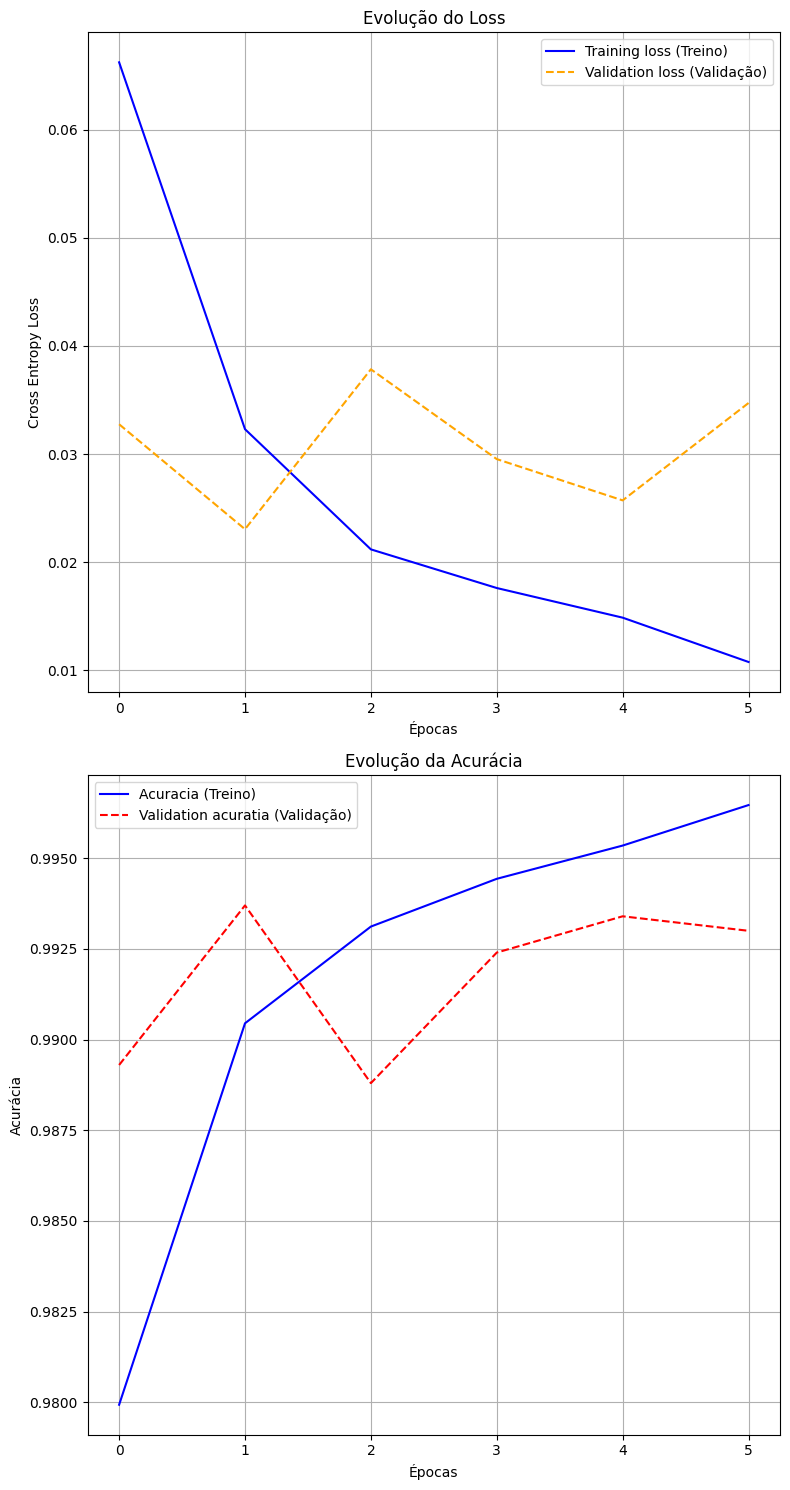

In [90]:
import matplotlib.pyplot as plt

fig, (ax1, ay1) = plt.subplots(2, 1, figsize=(8, 15))

ax1.plot(metricas['train_loss'], label=f'Training loss (Treino)', color='blue', linestyle='-')
ax1.plot(metricas['val_loss'], label=f'Validation loss (Validação)', color='orange', linestyle='--')

ax1.set_title("Evolução do Loss")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True)

ay1.plot(metricas['train_acc'], label=f'Acuracia (Treino)', color='blue', linestyle='-')

ay1.plot([acc.cpu().item() for acc in metricas['val_acc']], label=f'Validation acuratia (Validação)', color='red', linestyle='--')

ay1.set_title("Evolução da Acurácia")
ay1.set_xlabel("Épocas")
ay1.set_ylabel("Acurácia")
ay1.legend()
ay1.grid(True)

plt.tight_layout()
plt.show()

In [91]:
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

In [92]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [93]:
for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(512, 10)

parametros_para_treinar = filter(lambda p: p.requires_grad, model.parameters())
optimizer = Adam(parametros_para_treinar, lr=0.001)

In [94]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [95]:
model.to(device)
total_step = len(train_loader)

metricas = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

# Listas vazias
loss_list = []
acc_list = []

train_loss_epoch = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        running_corrects += torch.sum(predicted == labels.data)

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    metricas['train_loss'].append(epoch_loss)
    metricas['train_acc'].append(epoch_acc.cpu().item())

    print(f">>> Final da Época {epoch+1}: Loss Média: {epoch_loss:.4f}, Acc Média: {epoch_acc:.4f}")

    model.eval()
    val_loss_cum = 0.0
    val_corrects = 0
    y_true_epoch = []
    y_pred_epoch = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss_cum += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_corrects += torch.sum(predicted == labels.data)

            y_true_epoch.extend(labels.cpu().numpy())
            y_pred_epoch.extend(predicted.cpu().numpy())



    metricas['val_loss'].append(val_loss_cum / len(test_dataset))
    metricas['val_acc'].append(val_corrects.double() / len(test_dataset))
    metricas['val_f1'].append(f1_score(y_true_epoch, y_pred_epoch, average='weighted'))

    print(f"F1-Score: {metricas['val_f1'][-1]:.4f}")

Época [1/6], Step [100/1875], Loss: 0.1854
Época [1/6], Step [200/1875], Loss: 0.1528
Época [1/6], Step [300/1875], Loss: 0.0115
Época [1/6], Step [400/1875], Loss: 0.0193
Época [1/6], Step [500/1875], Loss: 0.0282
Época [1/6], Step [600/1875], Loss: 0.0646
Época [1/6], Step [700/1875], Loss: 0.0607
Época [1/6], Step [800/1875], Loss: 0.0212
Época [1/6], Step [900/1875], Loss: 0.0515
Época [1/6], Step [1000/1875], Loss: 0.0341
Época [1/6], Step [1100/1875], Loss: 0.0331
Época [1/6], Step [1200/1875], Loss: 0.0005
Época [1/6], Step [1300/1875], Loss: 0.0045
Época [1/6], Step [1400/1875], Loss: 0.0448
Época [1/6], Step [1500/1875], Loss: 0.0442
Época [1/6], Step [1600/1875], Loss: 0.3979
Época [1/6], Step [1700/1875], Loss: 0.1115
Época [1/6], Step [1800/1875], Loss: 0.0568
>>> Final da Época 1: Loss Média: 0.0779, Acc Média: 0.9764
F1-Score: 0.9899
Época [2/6], Step [100/1875], Loss: 0.0101
Época [2/6], Step [200/1875], Loss: 0.0899
Época [2/6], Step [300/1875], Loss: 0.0095
Época [2/6]

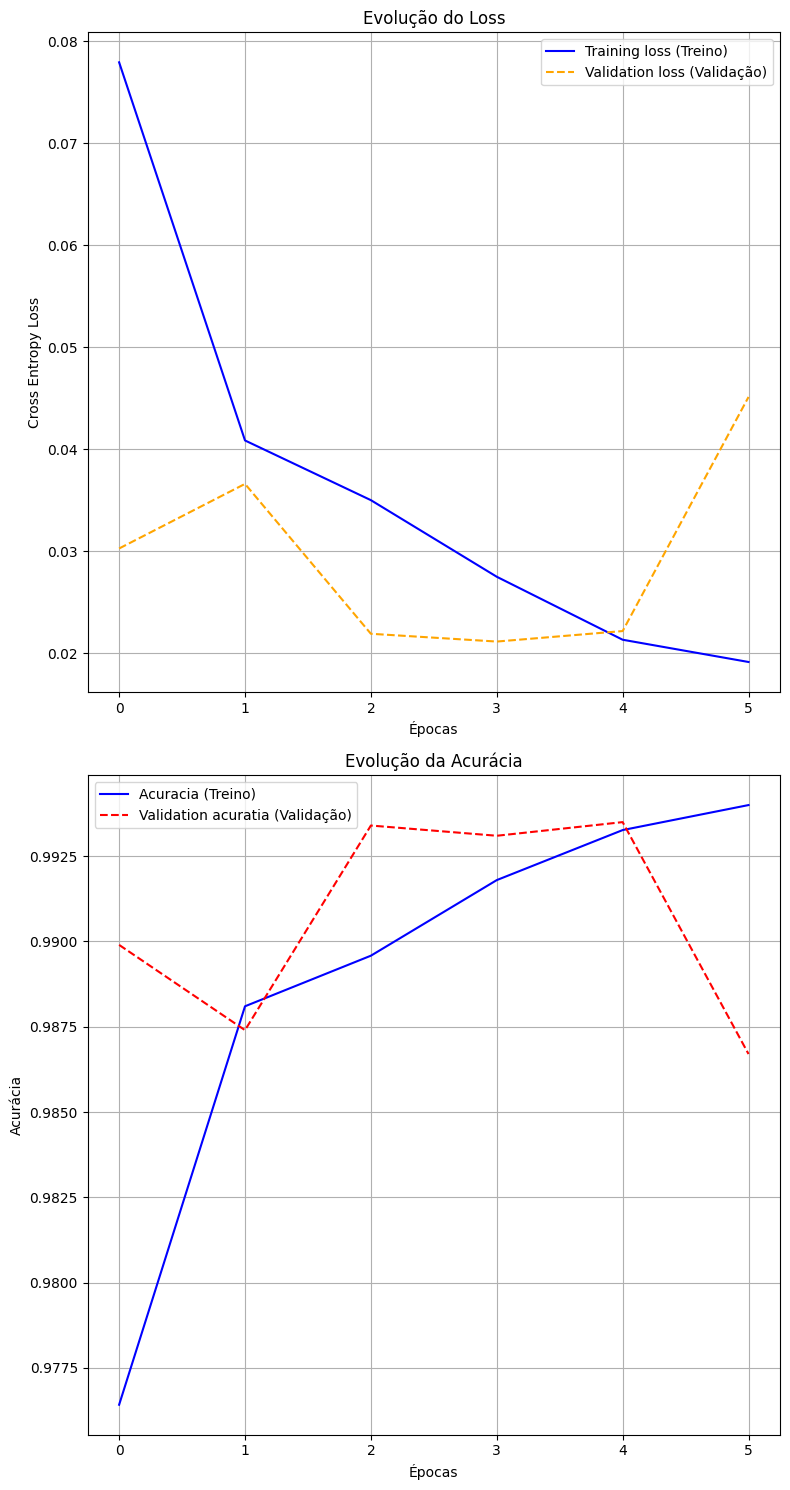

In [96]:
import matplotlib.pyplot as plt

fig, (ax1, ay1) = plt.subplots(2, 1, figsize=(8, 15))

ax1.plot(metricas['train_loss'], label=f'Training loss (Treino)', color='blue', linestyle='-')
ax1.plot(metricas['val_loss'], label=f'Validation loss (Validação)', color='orange', linestyle='--')

ax1.set_title("Evolução do Loss")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True)

ay1.plot(metricas['train_acc'], label=f'Acuracia (Treino)', color='blue', linestyle='-')

ay1.plot([acc.cpu().item() for acc in metricas['val_acc']], label=f'Validation acuratia (Validação)', color='red', linestyle='--')

ay1.set_title("Evolução da Acurácia")
ay1.set_xlabel("Épocas")
ay1.set_ylabel("Acurácia")
ay1.legend()
ay1.grid(True)

plt.tight_layout()
plt.show()

In [97]:
ResNet18 = torchvision.models.resnet18()
ResNet18.fc = nn.Linear(512, 10)

In [98]:
model = ResNet18
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [99]:
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

optimizer = Adam(model.parameters(), lr=learning_rate)

In [100]:
total_step = len(train_loader)
total_step

1875

In [101]:
model.to(device)
total_step = len(train_loader)

metricas = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

# Listas vazias
loss_list = []
acc_list = []

train_loss_epoch = 0.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        running_corrects += torch.sum(predicted == labels.data)

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], "
                  f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    metricas['train_loss'].append(epoch_loss)
    metricas['train_acc'].append(epoch_acc.cpu().item())

    print(f">>> Final da Época {epoch+1}: Loss Média: {epoch_loss:.4f}, Acc Média: {epoch_acc:.4f}")

    model.eval()
    val_loss_cum = 0.0
    val_corrects = 0
    y_true_epoch = []
    y_pred_epoch = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_loss_cum += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_corrects += torch.sum(predicted == labels.data)

            y_true_epoch.extend(labels.cpu().numpy())
            y_pred_epoch.extend(predicted.cpu().numpy())



    metricas['val_loss'].append(val_loss_cum / len(test_dataset))
    metricas['val_acc'].append(val_corrects.double() / len(test_dataset))
    metricas['val_f1'].append(f1_score(y_true_epoch, y_pred_epoch, average='weighted'))

    print(f"F1-Score: {metricas['val_f1'][-1]:.4f}")

Época [1/6], Step [100/1875], Loss: 0.1160
Época [1/6], Step [200/1875], Loss: 0.1252
Época [1/6], Step [300/1875], Loss: 0.0475
Época [1/6], Step [400/1875], Loss: 0.0409
Época [1/6], Step [500/1875], Loss: 0.0095
Época [1/6], Step [600/1875], Loss: 0.0974
Época [1/6], Step [700/1875], Loss: 0.0078
Época [1/6], Step [800/1875], Loss: 0.2653
Época [1/6], Step [900/1875], Loss: 0.0233
Época [1/6], Step [1000/1875], Loss: 0.0098
Época [1/6], Step [1100/1875], Loss: 0.0150
Época [1/6], Step [1200/1875], Loss: 0.0300
Época [1/6], Step [1300/1875], Loss: 0.0236
Época [1/6], Step [1400/1875], Loss: 0.0888
Época [1/6], Step [1500/1875], Loss: 0.0128
Época [1/6], Step [1600/1875], Loss: 0.0333
Época [1/6], Step [1700/1875], Loss: 0.0060
Época [1/6], Step [1800/1875], Loss: 0.0043
>>> Final da Época 1: Loss Média: 0.1082, Acc Média: 0.9666
F1-Score: 0.9871
Época [2/6], Step [100/1875], Loss: 0.0863
Época [2/6], Step [200/1875], Loss: 0.0407
Época [2/6], Step [300/1875], Loss: 0.0138
Época [2/6]

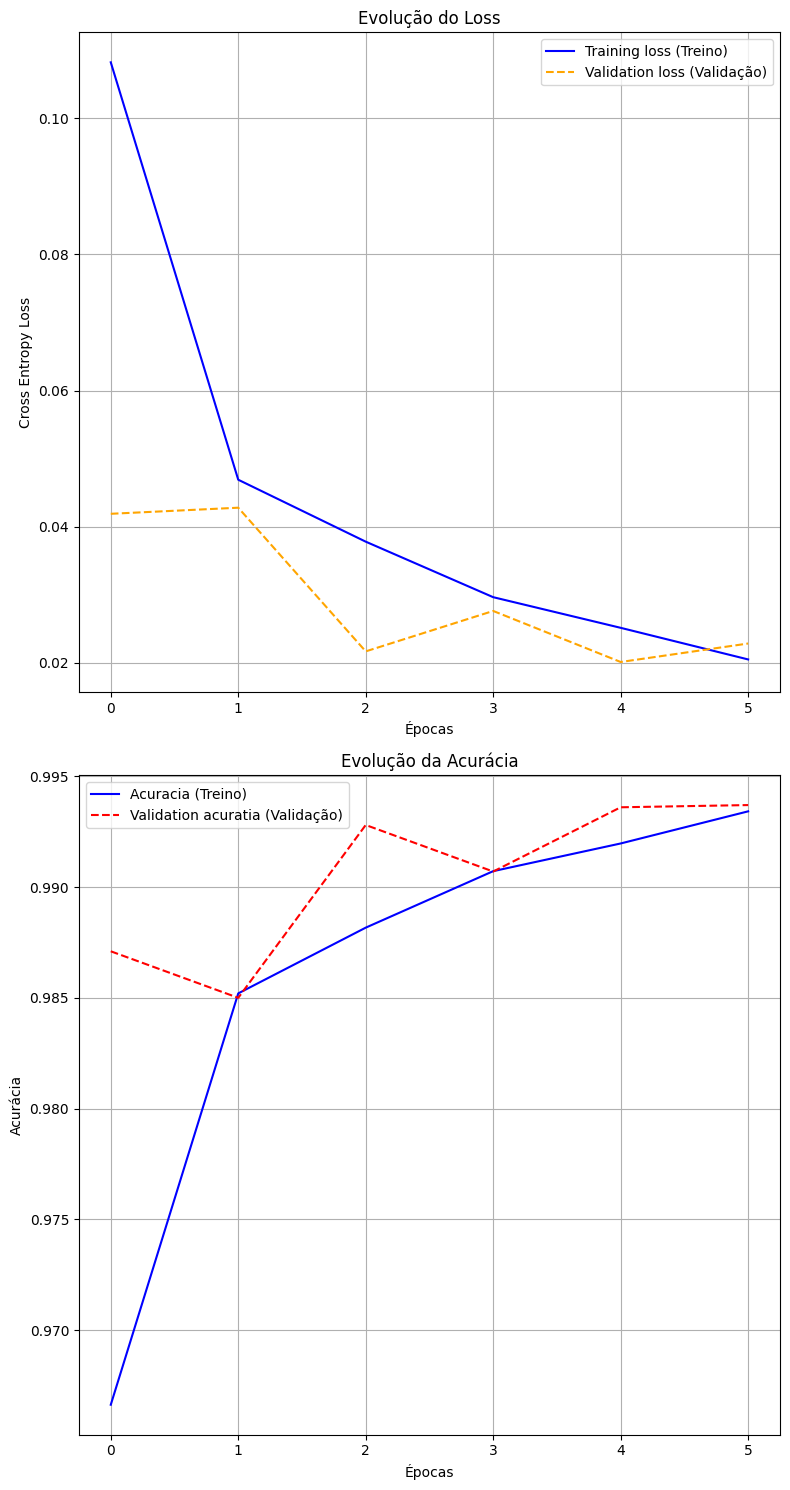

In [102]:
import matplotlib.pyplot as plt

fig, (ax1, ay1) = plt.subplots(2, 1, figsize=(8, 15))

ax1.plot(metricas['train_loss'], label=f'Training loss (Treino)', color='blue', linestyle='-')
ax1.plot(metricas['val_loss'], label=f'Validation loss (Validação)', color='orange', linestyle='--')

ax1.set_title("Evolução do Loss")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True)

ay1.plot(metricas['train_acc'], label=f'Acuracia (Treino)', color='blue', linestyle='-')

ay1.plot([acc.cpu().item() for acc in metricas['val_acc']], label=f'Validation acuratia (Validação)', color='red', linestyle='--')

ay1.set_title("Evolução da Acurácia")
ay1.set_xlabel("Épocas")
ay1.set_ylabel("Acurácia")
ay1.legend()
ay1.grid(True)

plt.tight_layout()
plt.show()